# Summary Stats on a Proposed Rebalance

In [127]:
import json
import pandas as pd
from glob import glob

paths = glob('../data/*')




In [128]:
def make_in_out_apr_df(state_of_destinations) -> pd.DataFrame:
    df = pd.DataFrame()
    df['name'] = [dest['name'] for dest in state_of_destinations['destStates']]
    df['totalAprIn'] = [dest['totalAprIn'] for dest in state_of_destinations['destStates']]
    df['totalAprOut'] = [dest['totalAprOut'] for dest in state_of_destinations['destStates']]
    df['destination'] = [dest['address'] for dest in state_of_destinations['destStates']]
    df['lp_safePrice'] = [dest['spotPrice'] for dest in state_of_destinations['destStates']]
    df['lp_spotPrice'] = [dest['safePrice'] for dest in state_of_destinations['destStates']]
    return df


def build_summary_data(path:str) -> dict:
    
    with open(path, 'r') as fin: 
        data = json.load(fin)
    
    state_of_destinations = data.pop('sod')
    apr_df = make_in_out_apr_df(state_of_destinations)
    
    destinationOut_name = apr_df[apr_df['destination'] == data['destinationOut']]['name'].values[0]
    destinationIn_name = apr_df[apr_df['destination'] == data['destinationIn']]['name'].values[0]
    
    totalAprIn = float(apr_df[apr_df['destination'] == data['destinationIn']]['totalAprIn'].values[0] * 100)
    totalAprOut = float(apr_df[apr_df['destination'] == data['destinationOut']]['totalAprOut'].values[0] * 100)
    
    amountOutETH = int(data['amountOutETH']) / 1e18
    minAmountInETH = int(data['minAmountIn']) / 1e18
    
    expectedAPRIncrease = totalAprIn - totalAprOut
    slippage_percent = 100 - ((100 * int(data['minAmountInETH'])) / int(data['amountOutETH']))
    
    swap_cost_eth = amountOutETH - minAmountInETH
    
    predicted_annualized_gain = ((totalAprIn / 100) * minAmountInETH) - (totalAprOut/100 * amountOutETH)
    
    min_break_even_days = (swap_cost_eth * 365) / predicted_annualized_gain
    
    proposedRebalanceImpacts = {
        'date': pd.to_datetime(data['timestamp'], unit='s'),
        'destinationOut_name':destinationOut_name[15:], 'destinationIn_name':destinationIn_name[15:],
        'totalAprOut': totalAprOut, 'totalAprIn':totalAprIn,
        'amountOutETH':amountOutETH, 'minAmountInETH':minAmountInETH, 'swap_cost_eth': swap_cost_eth,
        'expectedAPRIncrease': expectedAPRIncrease ,'slippagePercent': slippage_percent,
        'predicted_annualized_gain':predicted_annualized_gain, 'min_break_even_days':min_break_even_days
    }
    return proposedRebalanceImpacts

rebalance_df = pd.DataFrame.from_records(build_summary_data(path) for path in paths)
rebalance_df = rebalance_df.set_index('date')
rebalance_df.sort_index()

,destinationOut_name,destinationIn_name,totalAprOut,totalAprIn,amountOutETH,minAmountInETH,swap_cost_eth,expectedAPRIncrease,slippagePercent,predicted_annualized_gain,min_break_even_days
date,,,,,,,,,,,
2024-07-12 23:20:47,Ether-osETH/rETH,Ether-Balancer ETHx/wstETH,6.847850,10.772455,8.912144,8.804792,0.107352,3.924605,0.462451,0.338202,115.858688
2024-07-29 21:08:19,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.808693,11.861191,35.662150,34.759751,0.902399,5.052498,0.276671,1.694794,194.345507
2024-07-30 04:37:06,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.801833,11.814118,35.662153,34.753961,0.908192,5.012286,0.293599,1.680194,197.292808
2024-07-30 04:55:08,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.801833,11.814118,35.662153,34.753970,0.908183,5.012286,0.293573,1.680195,197.290723
2024-07-30 23:29:57,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.302030,12.031603,35.659201,34.752917,0.906284,5.729573,0.278808,1.934079,171.034139
2024-07-30 23:41:38,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.302030,12.031603,35.659201,34.800815,0.858386,5.729573,0.141370,1.939842,161.513577
2024-07-31 20:45:09,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.297411,11.647200,35.660445,34.792283,0.868162,5.349789,0.162350,1.806642,175.396655
2024-07-31 21:11:41,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.297411,11.647200,35.660445,34.793837,0.866608,5.349789,0.157891,1.806823,175.065180
2024-07-31 21:54:06,Ether-osETH/rETH,Ether-Curve.fi Factory Pool: ETHx-ETH,6.297411,11.647200,35.660445,34.794553,0.865891,5.349789,0.155837,1.806906,174.912401


None of these rebalances would pass because the days to break even are always much greater than the swap cost off set period. Actual execution is much better. 

In [149]:
with open(paths[2], 'r') as fin: 
    data = json.load(fin)


token_symbols = {
    '0xEeeeeEeeeEeEeeEeEeEeeEEEeeeeEeeeeeeeEEeE': 'ETH',
    '0xA35b1B31Ce002FBF2058D22F30f95D405200A15b': 'ETHx',
    '0xae78736Cd615f374D3085123A210448E74Fc6393': 'rETH',
    '0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2': 'wETH',
    '0xf1C9acDc66974dFB6dEcB12aA385b9cD01190E38': 'osETH',
    '0x7f39C581F595B53c5cb19bD0b3f8dA6c935E2Ca0': 'wstETH'
}

def _address_to_name(addr:str):
    return token_symbols[addr] # stub, use on-chain calls when needed

def _handle_lifi_swap(step:dict):
    payload = step['payload']
    
    tokenTo = payload['action']['fromToken']['symbol']
    tokenFrom = payload['action']['toToken']['symbol']
    
    estimate = payload['estimate']
    toAmount = int(estimate['toAmount'])
    fromAmount = int(estimate['fromAmount'])

    return  {
        'dex': step['dex'], 'type': 'swap',
        'tokenBought': tokenTo, 'tokenSold': tokenFrom, 'amountBought':toAmount, 'amountSold':fromAmount,
    }
    

def _handle_0x_swap(step:dict):
    return {
        'dex': step['dex'], 'type': 'swap',
        'tokenBought': _address_to_name(step['tokenIn']), 'tokenSold':_address_to_name(step['tokenOut']),
        'amountBought':int(step['payload']['grossBuyAmount']), 'amountSold':int(step['payload']['grossSellAmount']),
    }

def _handle_wrap(step:dict):
    return step

def _handle_unwrap(step:dict):
    return step

def _handle_add_liqudity(step:dict):
    token0Out, token1Out = step['tokens']
    token0_amount, token1_amount = step['amounts']
    return {
        'type': step['stepType'],
        'token0Out':_address_to_name(token0Out), 'token0_amount':token0_amount,
        'token1Out':_address_to_name(token1Out), 'token1_amount':token1_amount,
    } 
    

def _handle_remove_liqudity(step:dict):
    token0Out, token1Out = step['tokens']
    token0_amount, token1_amount = step['minTokenAmounts']
    return {
        'type': step['stepType'],
        'token0Out':_address_to_name(token0Out), 'token0_amount':int(token0_amount),
        'token1Out':_address_to_name(token1Out), 'token1_amount':int(token1_amount),
    } 



short_details = []
for step in data['steps']:
    
    if step['stepType'] == 'swap':
        if step['dex'] == '0x':
            details = _handle_0x_swap(step)
        elif  step['dex'] == 'lifi':
            details = _handle_lifi_swap(step)
        else:
            print(step)
            raise ValueError('bad path')
    
    elif step['stepType'] == 'removeLiquidity':
        details = _handle_remove_liqudity(step)
        
    elif step['stepType'] == 'addLiquidity':
        details = _handle_add_liqudity(step)
        
    elif step['stepType'] == 'unwrap':
        details = _handle_unwrap(step)
        
    elif step['stepType'] == 'wrap':
        details = _handle_wrap(step)
        
    else:
        print(step)
        raise ValueError('bad path')

    short_details.append(details)
    
short_details

[{'type': 'removeLiquidity',
  'token0Out': 'osETH',
  'token0_amount': 20371313657141530624,
  'token1Out': 'rETH',
  'token1_amount': 13218964856233213952},
 {'dex': 'lifi',
  'type': 'swap',
  'tokenBought': 'osETH',
  'tokenSold': 'ETHx',
  'amountBought': 20152525797062751892,
  'amountSold': 20371313657141530624},
 {'dex': 'lifi',
  'type': 'swap',
  'tokenBought': 'rETH',
  'tokenSold': 'WETH',
  'amountBought': 11983449495253360640,
  'amountSold': 10714937400063143936},
 {'stepType': 'unwrap',
  'amountIn': '11970867472455819264',
  'amountOut': '11970867472455819264'},
 {'dex': 'lifi',
  'type': 'swap',
  'tokenBought': 'rETH',
  'tokenSold': 'ETHx',
  'amountBought': 2703519263054399488,
  'amountSold': 2504027456170070016},
 {'type': 'addLiquidity',
  'token0Out': 'ETHx',
  'token0_amount': '22832047355606281728',
  'token1Out': 'ETH',
  'token1_amount': '11970867472455819264'}]

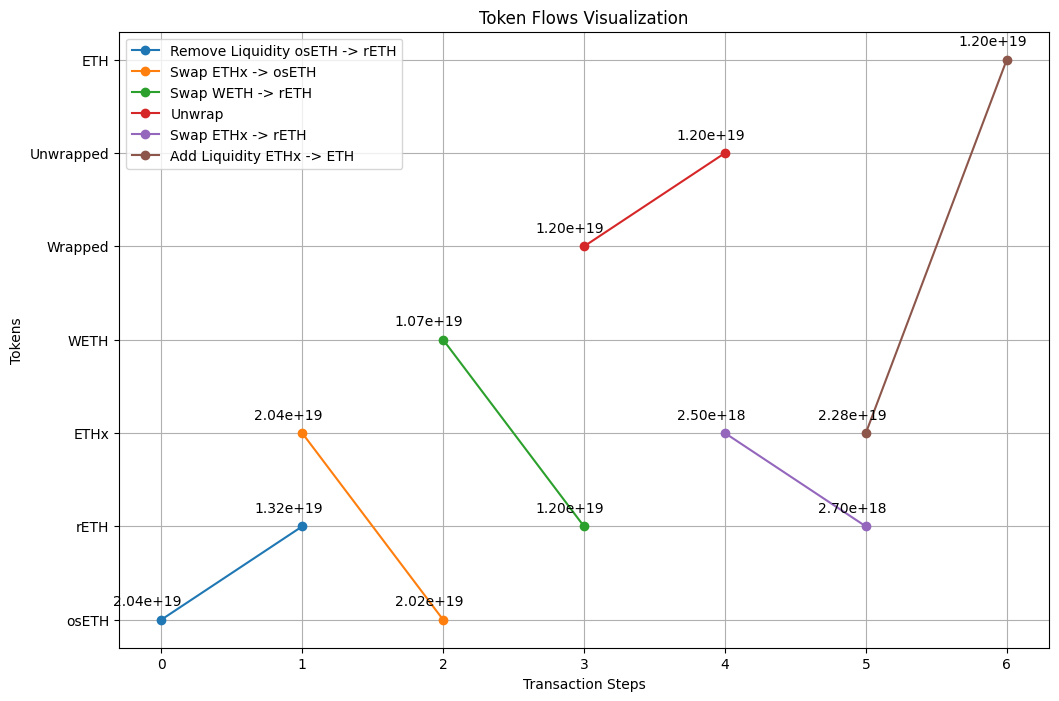

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = [
    {'type': 'removeLiquidity', 'token0Out': 'osETH', 'token0_amount': 20371313657141530624, 'token1Out': 'rETH', 'token1_amount': 13218964856233213952},
    {'dex': 'lifi', 'type': 'swap', 'tokenBought': 'osETH', 'tokenSold': 'ETHx', 'amountBought': 20152525797062751892, 'amountSold': 20371313657141530624},
    {'dex': 'lifi', 'type': 'swap', 'tokenBought': 'rETH', 'tokenSold': 'WETH', 'amountBought': 11983449495253360640, 'amountSold': 10714937400063143936},
    {'stepType': 'unwrap', 'amountIn': 11970867472455819264, 'amountOut': 11970867472455819264},
    {'dex': 'lifi', 'type': 'swap', 'tokenBought': 'rETH', 'tokenSold': 'ETHx', 'amountBought': 2703519263054399488, 'amountSold': 2504027456170070016},
    {'type': 'addLiquidity', 'token0Out': 'ETHx', 'token0_amount': 22832047355606281728, 'token1Out': 'ETH', 'token1_amount': 11970867472455819264}
]

# Convert the data to a DataFrame
df = pd.json_normalize(data)

# Fill NaN values with zero for consistency in operations
df = df.fillna(0)

# Function to plot token flows
def plot_token_flows(df):
    plt.figure(figsize=(12, 8))
    token_mappings = {
        'removeLiquidity': ('token0Out', 'token1Out', 'token0_amount', 'token1_amount'),
        'swap': ('tokenSold', 'tokenBought', 'amountSold', 'amountBought'),
        'unwrap': ('amountIn', 'amountOut'),
        'addLiquidity': ('token0Out', 'token1Out', 'token0_amount', 'token1_amount')
    }
    
    for index, row in df.iterrows():
        if row['type'] == 'removeLiquidity':
            token0, token1, amount0, amount1 = token_mappings['removeLiquidity']
            plt.plot([index, index + 1], [row[token0], row[token1]], label=f"Remove Liquidity {row[token0]} -> {row[token1]}", marker='o')
            plt.annotate(f"{row[amount0]:.2e}", (index, row[token0]), textcoords="offset points", xytext=(-10,10), ha='center')
            plt.annotate(f"{row[amount1]:.2e}", (index + 1, row[token1]), textcoords="offset points", xytext=(-10,10), ha='center')
        
        elif row['type'] == 'swap':
            token_sold, token_bought, amount_sold, amount_bought = token_mappings['swap']
            plt.plot([index, index + 1], [row[token_sold], row[token_bought]], label=f"Swap {row[token_sold]} -> {row[token_bought]}", marker='o')
            plt.annotate(f"{row[amount_sold]:.2e}", (index, row[token_sold]), textcoords="offset points", xytext=(-10,10), ha='center')
            plt.annotate(f"{row[amount_bought]:.2e}", (index + 1, row[token_bought]), textcoords="offset points", xytext=(-10,10), ha='center')
        
        elif row['stepType'] == 'unwrap':
            plt.plot([index, index + 1], ['Wrapped', 'Unwrapped'], label="Unwrap", marker='o')
            plt.annotate(f"{row['amountIn']:.2e}", (index, 'Wrapped'), textcoords="offset points", xytext=(-10,10), ha='center')
            plt.annotate(f"{row['amountOut']:.2e}", (index + 1, 'Unwrapped'), textcoords="offset points", xytext=(-10,10), ha='center')
        
        elif row['type'] == 'addLiquidity':
            token0, token1, amount0, amount1 = token_mappings['addLiquidity']
            plt.plot([index, index + 1], [row[token0], row[token1]], label=f"Add Liquidity {row[token0]} -> {row[token1]}", marker='o')
            plt.annotate(f"{row[amount0]:.2e}", (index, row[token0]), textcoords="offset points", xytext=(-10,10), ha='center')
            plt.annotate(f"{row[amount1]:.2e}", (index + 1, row[token1]), textcoords="offset points", xytext=(-10,10), ha='center')
    
    plt.title('Token Flows Visualization')
    plt.xlabel('Transaction Steps')
    plt.ylabel('Tokens')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_token_flows(df)
